## Apriori Algorithm

Apriori is a classic algorithm used in data mining for learning association rules. It is designed to operate on databases containing transactions, such as those found in retail sales. The algorithm identifies frequent itemsets in the database and then derives association rules from these itemsets. The main idea behind Apriori is that if an itemset is frequent, then all of its subsets must also be frequent. This property allows the algorithm to efficiently prune the search space when looking for frequent itemsets.

In [422]:
!pip install mlxtend


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [423]:
import pandas as pd
import random

# Reproducibility
random.seed(42)

# Dish recipes
recipes = {
    "Carbonara": ["Pasta", "Bacon", "Egg", "Parmesan"],
    "Chicken Tikka Masala": ["Chicken", "Tomato", "Yogurt", "Garlic"],
    "Tacos": ["Tortilla", "Beef", "Tomato", "Cheese"],
    "Sushi": ["Rice", "Seaweed", "Fish"],
    "Lasagna": ["Pasta", "Beef", "Tomato", "Cheese"],
    "Pad Thai": ["Noodles", "Egg", "Tofu", "Peanut"],
    "Falafel": ["Chickpea", "Garlic", "Herb"],
    "Ramen": ["Noodles", "Egg", "Pork"],
    "Paella": ["Rice", "Seafood", "Saffron"],
    "Beef Stroganoff": ["Beef", "Mushroom", "Cream"]
}

# Optional extra ingredients
extras = [
    "Onion", "Pepper", "Salt", "Olive Oil",
    "Butter", "Chili", "Lemon", "Parsley"
]

transactions = []

for _ in range(100):
    dish = random.choice(list(recipes.keys()))

    # Base ingredients
    ingredients = recipes[dish].copy()

    # Add 0-2 random extras
    n_extra = random.randint(0, 2)
    ingredients.extend(random.sample(extras, n_extra))

    transactions.append({
        "Dish": dish,
        "Ingredients": ingredients
    })

df = pd.DataFrame(transactions)

In [424]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Apriori needs data in True/False format
encoder = TransactionEncoder()
encoded_array = encoder.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(encoded_array, columns=encoder.columns_)

In [425]:
frequent_itemsets = apriori(df_encoded, min_support=0.2, use_colnames=True)
print("Total Frequent Item-sets:", frequent_itemsets.shape[0])

Total Frequent Item-sets: 3


In [426]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

rules = rules[rules['antecedents'].apply(lambda x: len(x) >= 1) &
    rules['consequents'].apply(lambda x: len(x) >= 1)]

print("Association Rules:", rules.shape[0])
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Association Rules: 2
     antecedents    consequents  support  confidence  lift
0         (Dish)  (Ingredients)      1.0         1.0   1.0
1  (Ingredients)         (Dish)      1.0         1.0   1.0


/Users/macbook/.pyenv/versions/3.11.9/lib/python3.11/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


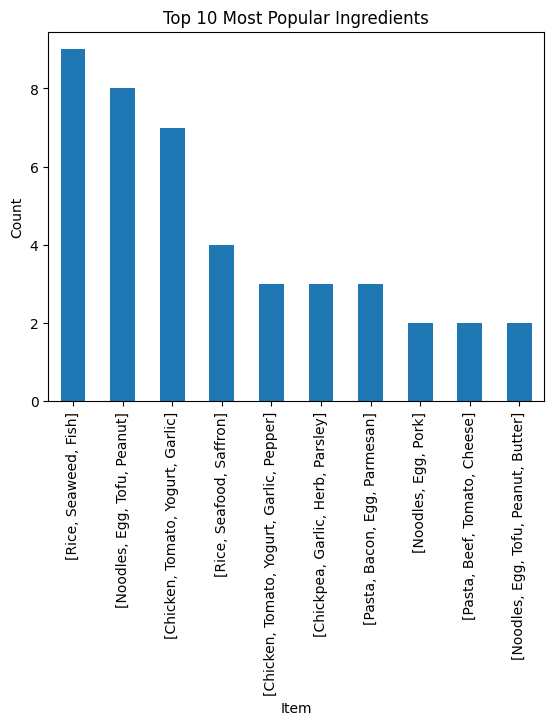

In [427]:
import matplotlib.pyplot as plt

top_items = df['Ingredients'].value_counts().head(10)

top_items.plot(kind='bar', title='Top 10 Most Popular Ingredients')
plt.xlabel("Item")
plt.ylabel("Count")
plt.show()